# Notebook 05 — LTR Dataset Reformulation

Convert feature-engineered task datasets into candidate `(Task_ID, Employee_ID)` pairs for learning-to-rank.

**Each row:** one task + one candidate employee + one relevance label.

> **Implicit-negative note:** Employees not historically assigned to a task are treated as implicit negatives. This means the assignment was not observed, not that the employee was definitively unsuitable.

## Step 1 — Imports and Load Inputs

In [1]:
import pandas as pd
import numpy as np
import json
import os
import warnings
import datetime
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
NEGATIVES_PER_TASK = 20
np.random.seed(RANDOM_STATE)

DATA_DIR   = "../data/processed/split_datasets"
OUTPUT_DIR = "../data/processed/ltr_datasets"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_df = pd.read_csv(f"{DATA_DIR}/feature_engineered_train_dataset.csv")
val_df   = pd.read_csv(f"{DATA_DIR}/feature_engineered_validation_dataset.csv")
test_df  = pd.read_csv(f"{DATA_DIR}/feature_engineered_test_dataset.csv")

employee_skill_profiles      = pd.read_csv(f"{DATA_DIR}/employee_skill_profiles.csv")
employee_historical_profiles = pd.read_csv(f"{DATA_DIR}/employee_historical_profiles.csv")

with open(f"{DATA_DIR}/model_metadata.json") as f:
    metadata = json.load(f)

SKILL_COLUMNS        = metadata["task_skill_columns"]
EMP_SKILL_PROFILE_COLS = metadata["employee_skill_profile_cols"]

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")
print(f"Employee skill profiles: {employee_skill_profiles.shape}")
print(f"Employee historical profiles: {employee_historical_profiles.shape}")
print(f"Skill columns: {SKILL_COLUMNS}")

def drop_leakage_columns(dset):
    bad_cols = [
        c for c in dset.columns
        if c.startswith("FLAG_LEAKAGE_")
    ]

    bad_cols += [
        "Hours_Spent",
        "Work_Description",
        "Actual_Hours_Spent",
        "Timesheet_Work_Logs",
        "Timesheet_Logs_Count",
        "Task_Stage",
        "All_Collaborating_Employees",
        "Debug_Skill_Scores",
        "Task_Skills",
    ]

    bad_cols = list(dict.fromkeys(bad_cols))

    return dset.drop(
        columns=[
            c for c in bad_cols
            if c in dset.columns
        ],
        errors="ignore",
    )

train_df = drop_leakage_columns(train_df)
val_df = drop_leakage_columns(val_df)
test_df = drop_leakage_columns(test_df)

for dset in [train_df, val_df, test_df]:
    dset["Created_Date"] = pd.to_datetime(
        dset["Created_Date"],
        errors="coerce",
    )

def get_task_context(dset):
    return (
        dset[
            [
                "Task_ID",
                "Created_Date",
                "Project_Name",
            ]
        ]
        .sort_values(
            ["Created_Date", "Task_ID"]
        )
        .drop_duplicates(
            "Task_ID",
            keep="first",
        )
    )

task_context_train = get_task_context(train_df)
task_context_val = get_task_context(val_df)
task_context_test = get_task_context(test_df)

# DO NOT LOAD STATIC PROFILES FOR HISTORICAL ROWS


Train: (8314, 45), Val: (1588, 45), Test: (1728, 45)
Employee skill profiles: (49, 10)
Employee historical profiles: (49, 9)
Skill columns: ['Skill_Odoo_ERP_Development', 'Skill_Database_Management', 'Skill_Server_Administration', 'Skill_Project_Management', 'Skill_Software_Testing', 'Skill_Web_Development', 'Skill_Client_and_Functional_Support', 'Skill_Documentation', 'Skill_Training_and_Mentorship']


## Step 2 — Define Leakage Columns

## Step 3 — Verify Task-Level Split (No Leakage)

In [2]:
train_tasks = set(train_df["Task_ID"])
val_tasks   = set(val_df["Task_ID"])
test_tasks  = set(test_df["Task_ID"])

train_val_overlap  = train_tasks.intersection(val_tasks)
train_test_overlap = train_tasks.intersection(test_tasks)
val_test_overlap   = val_tasks.intersection(test_tasks)

print("Train unique tasks:      ", len(train_tasks))
print("Validation unique tasks: ", len(val_tasks))
print("Test unique tasks:       ", len(test_tasks))
print("Train/Validation task overlap:", len(train_val_overlap))
print("Train/Test task overlap:      ", len(train_test_overlap))
print("Validation/Test task overlap: ", len(val_test_overlap))

assert len(train_val_overlap)  == 0, "LEAKAGE: Train/Val!"
assert len(train_test_overlap) == 0, "LEAKAGE: Train/Test!"
assert len(val_test_overlap)   == 0, "LEAKAGE: Val/Test!"
print("All task-leakage assertions passed!")

Train unique tasks:       1709
Validation unique tasks:  366
Test unique tasks:        367
Train/Validation task overlap: 0
Train/Test task overlap:       0
Validation/Test task overlap:  0
All task-leakage assertions passed!


## Step 4 — Define Candidate Pool

In [3]:
TRAIN_EMPLOYEES = sorted(train_df["Employee_ID"].unique())
N_EMPLOYEES = len(TRAIN_EMPLOYEES)
print(f"Candidate pool: {N_EMPLOYEES} employees (training data only)")

cold_start_summary = {}
for name, dset in [("val", val_df), ("test", test_df)]:
    missing = set(dset["Employee_ID"].unique()) - set(TRAIN_EMPLOYEES)
    cold_start_summary[name] = sorted(missing)
    if missing:
        print(f"Cold-start employees in {name} (not in train): {sorted(missing)}")
    else:
        print(f"{name}: all employees present in training pool")

candidate_pool = pd.DataFrame({
    "Employee_ID": TRAIN_EMPLOYEES,
    "in_training": True,
})
candidate_pool.to_csv(f"{OUTPUT_DIR}/employee_candidate_pool.csv", index=False)
print(f"employee_candidate_pool.csv saved: {candidate_pool.shape}")

Candidate pool: 49 employees (training data only)
val: all employees present in training pool
test: all employees present in training pool
employee_candidate_pool.csv saved: (49, 2)


## Step 5 — Extract Task-Level Features

In [4]:
NON_TASK_COLS = [
    "Employee_ID", "Employee_Name", "Employee_Department",
    "Employee_Job_Position", "Task_Text", "Task_Name",
    "Task_Description", "Date", "Created_Date", "Deadline_Date",
    "Project_Name",
]

def get_task_features(dset):
    keep = [c for c in dset.columns if c not in NON_TASK_COLS]
    return dset.groupby("Task_ID")[keep].first().reset_index()

NON_TASK_COLS = [
    "Employee_ID", "Employee_Name", "Employee_Department",
    "Employee_Job_Position", "Task_Text", "Task_Name",
    "Task_Description", "Date", "Created_Date", "Deadline_Date",
    "Project_Name",
]

def get_task_features(dset):
    keep = [
        c for c in dset.columns
        if c not in NON_TASK_COLS and c != "Task_ID"
    ]
    return dset.groupby("Task_ID")[keep].first().reset_index()

task_feat_train = get_task_features(train_df)
task_feat_val   = get_task_features(val_df)
task_feat_test  = get_task_features(test_df)

print(f"Task features — train: {task_feat_train.shape}, val: {task_feat_val.shape}, test: {task_feat_test.shape}")
print(f"Task feature columns ({len(task_feat_train.columns)}): {list(task_feat_train.columns)}")

Task features — train: (1709, 29), val: (366, 29), test: (367, 29)
Task feature columns (29): ['Task_ID', 'Task_Priority', 'Estimated_Planned_Hours', 'Task_Text_Length', 'Task_Word_Count', 'Task_Description_Length', 'Task_Name_Length', 'Has_Task_Description', 'Created_Year', 'Created_Month', 'Created_DayOfWeek', 'Created_Quarter', 'Days_To_Deadline', 'Has_Deadline', 'Planned_Hours_Log', 'Planned_Task_Size', 'Task_Skill_Count', 'Skill_Odoo_ERP_Development', 'Skill_Database_Management', 'Skill_Server_Administration', 'Skill_Project_Management', 'Skill_Software_Testing', 'Skill_Web_Development', 'Skill_Client_and_Functional_Support', 'Skill_Documentation', 'Skill_Training_and_Mentorship', 'Project_Task_Count_Train', 'Project_Avg_Skill_Count_Train', 'Project_Avg_Planned_Hours_Train']


## Step 6 — Build Positive Assignments

In [5]:
def get_positive_assignments(dset):
    pos = dset[["Task_ID", "Employee_ID"]].drop_duplicates().copy()
    pos["relevance"] = 1
    return pos

pos_train = get_positive_assignments(train_df)
pos_val   = get_positive_assignments(val_df)
pos_test  = get_positive_assignments(test_df)

print(f"Positive pairs — train: {len(pos_train)}, val: {len(pos_val)}, test: {len(pos_test)}")
for name, pos in [("train", pos_train), ("val", pos_val), ("test", pos_test)]:
    multi = pos.groupby("Task_ID")["Employee_ID"].count()
    print(f"  {name}: {(multi > 1).sum()} tasks have multiple positive employees")

Positive pairs — train: 2425, val: 509, test: 487
  train: 315 tasks have multiple positive employees
  val: 71 tasks have multiple positive employees
  test: 56 tasks have multiple positive employees


## Step 7 — Smart Negative Sampling

In [6]:
def build_full_candidate_pairs(
    pos_df,
    employee_pool,
    name,
):
    task_to_positive = (
        pos_df
        .groupby("Task_ID")["Employee_ID"]
        .apply(set)
        .to_dict()
    )

    rows = []
    for task_id, positive_employees in task_to_positive.items():
        for employee_id in employee_pool:
            rows.append(
                {
                    "Task_ID": task_id,
                    "Employee_ID": employee_id,
                    "relevance": int(
                        employee_id in positive_employees
                    ),
                }
            )

    pairs = pd.DataFrame(rows)
    print(
        f"{name}: "
        f"{pairs['Task_ID'].nunique()} tasks, "
        f"{len(pairs)} pairs, "
        f"{pairs['Employee_ID'].nunique()} candidates"
    )
    return pairs

pairs_train = build_full_candidate_pairs(pos_train, TRAIN_EMPLOYEES, "train")
pairs_val = build_full_candidate_pairs(pos_val, TRAIN_EMPLOYEES, "validation")
pairs_test = build_full_candidate_pairs(pos_test, TRAIN_EMPLOYEES, "test")


train: 1709 tasks, 83741 pairs, 49 candidates
validation: 366 tasks, 17934 pairs, 49 candidates
test: 367 tasks, 17983 pairs, 49 candidates


## Step 8 — Merge Task Features

In [7]:
ltr_train = pairs_train.merge(task_feat_train, on="Task_ID", how="left")
ltr_val   = pairs_val.merge(task_feat_val,     on="Task_ID", how="left")
ltr_test  = pairs_test.merge(task_feat_test,   on="Task_ID", how="left")

print(f"After task merge — train: {ltr_train.shape}, val: {ltr_val.shape}, test: {ltr_test.shape}")

ltr_train = ltr_train.merge(task_context_train, on="Task_ID", how="left", validate="many_to_one")
ltr_val = ltr_val.merge(task_context_val, on="Task_ID", how="left", validate="many_to_one")
ltr_test = ltr_test.merge(task_context_test, on="Task_ID", how="left", validate="many_to_one")


After task merge — train: (83741, 31), val: (17934, 31), test: (17983, 31)


## Step 9 — Merge Employee Historical Profiles

In [8]:
import numpy as np

history_base_cols = [
    "Task_ID",
    "Employee_ID",
    "Created_Date",
    "Project_Name",
    "Estimated_Planned_Hours",
    "Task_Skill_Count",
    "Task_Text_Length",
    "Days_To_Deadline",
] + SKILL_COLUMNS

history_base_cols = [
    c for c in history_base_cols
    if c in train_df.columns
]

history_events = (
    train_df[history_base_cols]
    .drop_duplicates(["Task_ID", "Employee_ID"])
    .copy()
)

history_events["Created_Date"] = pd.to_datetime(history_events["Created_Date"], errors="coerce")
history_events = history_events.sort_values(["Employee_ID", "Created_Date", "Task_ID"]).reset_index(drop=True)

history_events["employee_historical_task_count"] = history_events.groupby("Employee_ID").cumcount() + 1

def add_running_mean(df, source_col, target_col):
    values = pd.to_numeric(df[source_col], errors="coerce")
    valid = values.notna().astype(int)
    running_sum = values.fillna(0).groupby(df["Employee_ID"]).cumsum()
    running_count = valid.groupby(df["Employee_ID"]).cumsum()
    df[target_col] = (running_sum / running_count.replace(0, np.nan)).fillna(0)

if "Estimated_Planned_Hours" in history_events.columns:
    add_running_mean(history_events, "Estimated_Planned_Hours", "employee_historical_avg_planned_hours")

if "Task_Skill_Count" in history_events.columns:
    add_running_mean(history_events, "Task_Skill_Count", "employee_historical_avg_skill_count")

if "Task_Text_Length" in history_events.columns:
    add_running_mean(history_events, "Task_Text_Length", "employee_historical_avg_task_text_length")

if "Days_To_Deadline" in history_events.columns:
    add_running_mean(history_events, "Days_To_Deadline", "employee_historical_avg_deadline_days")

def cumulative_unique_count(series):
    seen = set()
    output = []
    for value in series:
        if pd.notna(value):
            seen.add(value)
        output.append(len(seen))
    return pd.Series(output, index=series.index)

history_events["employee_historical_unique_projects"] = (
    history_events.groupby("Employee_ID", group_keys=False)["Project_Name"].apply(cumulative_unique_count)
)
history_events["employee_historical_project_count"] = history_events["employee_historical_unique_projects"]
history_events["employee_log_task_count"] = np.log1p(history_events["employee_historical_task_count"])

for skill_col in SKILL_COLUMNS:
    if skill_col not in history_events.columns:
        continue
    values = history_events[skill_col].fillna(0).astype(float)
    running_sum = values.groupby(history_events["Employee_ID"]).cumsum()
    running_count = history_events.groupby("Employee_ID").cumcount() + 1
    profile_col = "Employee_Profile_" + skill_col
    history_events[profile_col] = running_sum / running_count

HISTORY_FEATURES = [
    "employee_historical_task_count",
    "employee_historical_avg_planned_hours",
    "employee_historical_avg_skill_count",
    "employee_historical_unique_projects",
    "employee_historical_project_count",
    "employee_historical_avg_task_text_length",
    "employee_historical_avg_deadline_days",
    "employee_log_task_count",
]
HISTORY_FEATURES = [c for c in HISTORY_FEATURES if c in history_events.columns]
EMP_PROFILE_SKILL_COLS = [c for c in history_events.columns if c.startswith("Employee_Profile_Skill_")]

def add_point_in_time_history(pair_df, history_df):
    outputs = []
    history_cols = ["Created_Date"] + HISTORY_FEATURES + EMP_PROFILE_SKILL_COLS
    for employee_id, employee_pairs in pair_df.groupby("Employee_ID", sort=False):
        employee_pairs = employee_pairs.sort_values("Created_Date").copy()
        employee_history = history_df[history_df["Employee_ID"] == employee_id][history_cols].sort_values("Created_Date").copy()
        if employee_history.empty:
            for col in (HISTORY_FEATURES + EMP_PROFILE_SKILL_COLS):
                employee_pairs[col] = 0.0
            outputs.append(employee_pairs)
            continue
        merged = pd.merge_asof(
            employee_pairs,
            employee_history,
            on="Created_Date",
            direction="backward",
            allow_exact_matches=False,
        )
        for col in (HISTORY_FEATURES + EMP_PROFILE_SKILL_COLS):
            merged[col] = merged[col].fillna(0)
        outputs.append(merged)
    return pd.concat(outputs, ignore_index=True)

ltr_train = add_point_in_time_history(ltr_train, history_events)
ltr_val = add_point_in_time_history(ltr_val, history_events)
ltr_test = add_point_in_time_history(ltr_test, history_events)


## Step 10 — Merge Employee Skill Profiles

## Step 11 — Task–Employee Skill Compatibility Features

In [9]:
def add_skill_compatibility(ltr_df):
    out = ltr_df.copy()
    task_skill_cols = [c for c in SKILL_COLUMNS if c in out.columns]
    profile_skill_cols = ["Employee_Profile_" + c for c in task_skill_cols]
    valid_pairs = [
        (task_col, profile_col)
        for task_col, profile_col in zip(task_skill_cols, profile_skill_cols)
        if profile_col in out.columns
    ]

    match_count = np.zeros(len(out), dtype=float)
    strength = np.zeros(len(out), dtype=float)

    for task_col, profile_col in valid_pairs:
        task_required = out[task_col].fillna(0).astype(float) > 0
        employee_has_skill = out[profile_col].fillna(0).astype(float) > 0
        match_count += (task_required & employee_has_skill).astype(int)
        strength += out[task_col].fillna(0).astype(float) * out[profile_col].fillna(0).astype(float)

    task_skill_count = (
        out[task_skill_cols].fillna(0).sum(axis=1) if task_skill_cols else pd.Series(0, index=out.index)
    )
    denominator = np.maximum(task_skill_count, 1)

    out["employee_task_skill_match_count"] = match_count
    out["employee_task_skill_match_ratio"] = match_count / denominator
    out["employee_task_skill_strength"] = strength / denominator
    out["employee_has_matching_skill"] = (match_count > 0).astype(int)
    return out

ltr_train = add_skill_compatibility(ltr_train)
ltr_val = add_skill_compatibility(ltr_val)
ltr_test = add_skill_compatibility(ltr_test)


## Step 12 — Project Experience Features (Training Data Only)

In [10]:
project_events = (
    history_events[
        ["Employee_ID", "Project_Name", "Created_Date", "Task_ID"]
    ]
    .drop_duplicates(["Employee_ID", "Project_Name", "Task_ID"])
    .sort_values(["Employee_ID", "Project_Name", "Created_Date", "Task_ID"])
    .copy()
)

project_events["employee_project_task_count"] = project_events.groupby(["Employee_ID", "Project_Name"]).cumcount() + 1

def add_point_in_time_project_history(pair_df, project_history):
    outputs = []
    for (employee_id, project_name), group in pair_df.groupby(["Employee_ID", "Project_Name"], dropna=False, sort=False):
        group = group.sort_values("Created_Date").copy()
        hist = project_history[
            (project_history["Employee_ID"] == employee_id) & (project_history["Project_Name"] == project_name)
        ][["Created_Date", "employee_project_task_count"]].sort_values("Created_Date")
        
        if hist.empty:
            group["employee_project_task_count"] = 0
            outputs.append(group)
            continue
            
        merged = pd.merge_asof(group, hist, on="Created_Date", direction="backward", allow_exact_matches=False)
        merged["employee_project_task_count"] = merged["employee_project_task_count"].fillna(0)
        outputs.append(merged)
        
    result = pd.concat(outputs, ignore_index=True)
    result["employee_has_project_experience"] = (result["employee_project_task_count"] > 0).astype(int)
    return result

ltr_train = add_point_in_time_project_history(ltr_train, project_events)
ltr_val = add_point_in_time_project_history(ltr_val, project_events)
ltr_test = add_point_in_time_project_history(ltr_test, project_events)


## Step 13 — Categorical Encoding (Fit on Train Only)

In [11]:
CAT_COLS = ["Task_Priority", "Planned_Task_Size"]
CAT_COLS = [c for c in CAT_COLS if c in ltr_train.columns]

ohe_encoders = {}
for col in CAT_COLS:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    ohe.fit(ltr_train[[col]].astype(str))
    ohe_encoders[col] = ohe
    for ltr_df in [ltr_train, ltr_val, ltr_test]:
        encoded = ohe.transform(ltr_df[[col]].astype(str))
        enc_cols = [f"{col}_{cat}" for cat in ohe.categories_[0]]
        for i, ecol in enumerate(enc_cols):
            ltr_df[ecol] = encoded[:, i]
    print(f"Encoded {col} -> {list(ohe.categories_[0])}")

joblib.dump(ohe_encoders, f"{OUTPUT_DIR}/ohe_encoders.pkl")
print("OHE encoders saved (fitted on training data only).")

Encoded Task_Priority -> ['Low', 'Normal']
Encoded Planned_Task_Size -> ['Large', 'Medium', 'Small']
OHE encoders saved (fitted on training data only).


## Step 14 — Define Model Feature Columns

In [12]:
PROHIBITED_FEATURES = {
    "Task_ID",
    "Employee_ID",
    "relevance",
    "Employee_Name",
    "Assigned_Employee_ID",
    "Assigned_Employee_Name",
    "Task_Name",
    "Task_Text",
    "Task_Description",
    "Project_Name",
    "Date",
    "Created_Date",
    "Deadline_Date",
    "Task_Priority",
    "Planned_Task_Size",
    "Hours_Spent",
    "Work_Description",
    "Actual_Hours_Spent",
    "Timesheet_Work_Logs",
    "Timesheet_Logs_Count",
    "Task_Stage",
    "All_Collaborating_Employees",
}

FEATURE_COLS = []
for col in ltr_train.columns:
    if col in PROHIBITED_FEATURES:
        continue
    if col.startswith("FLAG_LEAKAGE_"):
        continue
    if not pd.api.types.is_numeric_dtype(ltr_train[col]):
        continue
    FEATURE_COLS.append(col)

assert "Hours_Spent" not in FEATURE_COLS
assert "Work_Description" not in FEATURE_COLS
assert not any(c.startswith("FLAG_LEAKAGE_") for c in FEATURE_COLS)

print(f"Safe model features: {len(FEATURE_COLS)}")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"{i:02d}. {col}")


Safe model features: 54
01. Estimated_Planned_Hours
02. Task_Text_Length
03. Task_Word_Count
04. Task_Description_Length
05. Task_Name_Length
06. Has_Task_Description
07. Created_Year
08. Created_Month
09. Created_DayOfWeek
10. Created_Quarter
11. Days_To_Deadline
12. Has_Deadline
13. Planned_Hours_Log
14. Task_Skill_Count
15. Skill_Odoo_ERP_Development
16. Skill_Database_Management
17. Skill_Server_Administration
18. Skill_Project_Management
19. Skill_Software_Testing
20. Skill_Web_Development
21. Skill_Client_and_Functional_Support
22. Skill_Documentation
23. Skill_Training_and_Mentorship
24. Project_Task_Count_Train
25. Project_Avg_Skill_Count_Train
26. Project_Avg_Planned_Hours_Train
27. employee_historical_task_count
28. employee_historical_avg_planned_hours
29. employee_historical_avg_skill_count
30. employee_historical_unique_projects
31. employee_historical_project_count
32. employee_historical_avg_task_text_length
33. employee_historical_avg_deadline_days
34. employee_log_task

## Step 15 — EDA: Employee Task Distribution

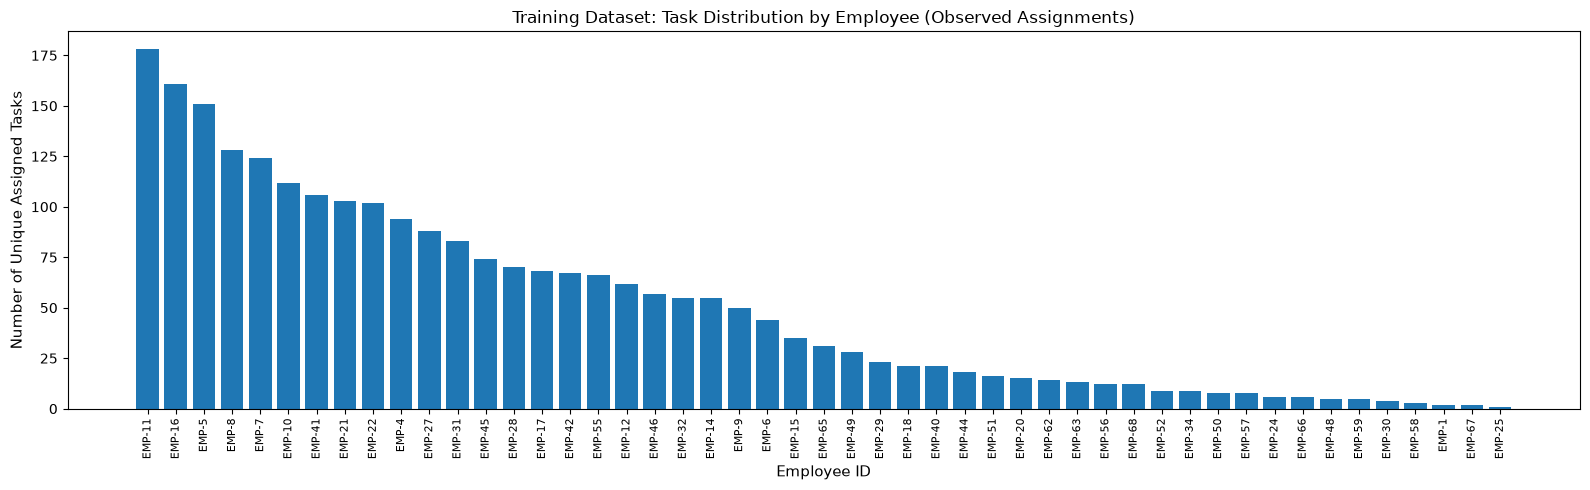

Note: High task count reflects observed workload, availability, or assignment behavior.
Do not interpret task count as a measure of employee ability.
Employees: 49, Max: 178, Min: 1


In [13]:
emp_task_dist = (
    pos_train
    .groupby("Employee_ID")["Task_ID"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Task_ID": "Task_Count"})
)

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(emp_task_dist["Employee_ID"].astype(str), emp_task_dist["Task_Count"], color="#1f77b4")
ax.set_xlabel("Employee ID", fontsize=11)
ax.set_ylabel("Number of Unique Assigned Tasks", fontsize=11)
ax.set_title("Training Dataset: Task Distribution by Employee (Observed Assignments)", fontsize=12)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.grid(False)
plt.tight_layout()
plt.show()

print("Note: High task count reflects observed workload, availability, or assignment behavior.")
print("Do not interpret task count as a measure of employee ability.")
print(f"Employees: {emp_task_dist.shape[0]}, Max: {emp_task_dist["Task_Count"].max()}, Min: {emp_task_dist["Task_Count"].min()}")

## Step 16 — Sort by Task_ID and Compute Group Arrays

In [14]:
ltr_train = ltr_train.sort_values("Task_ID").reset_index(drop=True)
ltr_val   = ltr_val.sort_values("Task_ID").reset_index(drop=True)
ltr_test  = ltr_test.sort_values("Task_ID").reset_index(drop=True)

train_group_sizes = ltr_train.groupby("Task_ID", sort=False).size().to_numpy()
val_group_sizes   = ltr_val.groupby("Task_ID",   sort=False).size().to_numpy()
test_group_sizes  = ltr_test.groupby("Task_ID",  sort=False).size().to_numpy()

assert train_group_sizes.sum() == len(ltr_train)
assert val_group_sizes.sum()   == len(ltr_val)
assert test_group_sizes.sum()  == len(ltr_test)

with open(f"{OUTPUT_DIR}/train_group_sizes.json",      "w") as f: json.dump(train_group_sizes.tolist(), f)
with open(f"{OUTPUT_DIR}/validation_group_sizes.json", "w") as f: json.dump(val_group_sizes.tolist(), f)
with open(f"{OUTPUT_DIR}/test_group_sizes.json",       "w") as f: json.dump(test_group_sizes.tolist(), f)

print(f"Train groups: {len(train_group_sizes)}, mean size: {train_group_sizes.mean():.1f}")
print(f"Val groups:   {len(val_group_sizes)}, mean size: {val_group_sizes.mean():.1f}")
print(f"Test groups:  {len(test_group_sizes)}, mean size: {test_group_sizes.mean():.1f}")
print("Group size files saved.")

Train groups: 1709, mean size: 49.0
Val groups:   366, mean size: 49.0
Test groups:  367, mean size: 49.0
Group size files saved.


## Step 17 — Save LTR Datasets

In [16]:
deployment_employee_profiles = (
    history_events
    .sort_values(["Employee_ID", "Created_Date", "Task_ID"])
    .groupby("Employee_ID", as_index=False)
    .tail(1)
)

deployment_cols = ["Employee_ID"] + HISTORY_FEATURES + EMP_PROFILE_SKILL_COLS
deployment_employee_profiles[deployment_cols].to_csv(
    f"{OUTPUT_DIR}/employee_deployment_profiles.csv", index=False
)

deployment_project_history = (
    project_events
    .groupby(["Employee_ID", "Project_Name"], as_index=False)
    .agg(employee_project_task_count=("employee_project_task_count", "max"))
)
deployment_project_history.to_csv(
    f"{OUTPUT_DIR}/employee_project_history.csv", index=False
)

candidate_pool_with_names = pd.DataFrame({
    "Employee_ID": TRAIN_EMPLOYEES
})

for profile_df in [
    train_df,
    employee_skill_profiles,
    employee_historical_profiles,
]:
    if {"Employee_ID", "Employee_Name"}.issubset(profile_df.columns):
        employee_names = (
            profile_df[["Employee_ID", "Employee_Name"]]
            .dropna(subset=["Employee_ID"])
            .drop_duplicates("Employee_ID")
        )
        candidate_pool_with_names = candidate_pool_with_names.merge(
            employee_names,
            on="Employee_ID",
            how="left",
        )
        break

candidate_pool_with_names.to_csv(
    f"{OUTPUT_DIR}/employee_candidate_pool.csv",
    index=False,
)

print(
    f"employee_candidate_pool.csv saved: "
    f"{candidate_pool_with_names.shape}"
)


employee_candidate_pool.csv saved: (49, 1)


In [18]:
ltr_train.to_csv(f"{OUTPUT_DIR}/ltr_train_dataset.csv",      index=False)
ltr_val.to_csv(f"{OUTPUT_DIR}/ltr_validation_dataset.csv",   index=False)
ltr_test.to_csv(f"{OUTPUT_DIR}/ltr_test_dataset.csv",        index=False)

# Define metadata column groups from columns already created above.
TASK_SKILL_COLS_PRESENT = [
    c for c in SKILL_COLUMNS
    if c in ltr_train.columns
]

EMP_HIST_COLS = [
    c for c in HISTORY_FEATURES
    if c in ltr_train.columns
]

EMP_SKILL_MERGE_COLS = [
    c for c in EMP_PROFILE_SKILL_COLS
    if c in ltr_train.columns
]

ltr_feature_meta = {
    "feature_cols": FEATURE_COLS,
    "n_features": len(FEATURE_COLS),
    "task_skill_cols": TASK_SKILL_COLS_PRESENT,
    "emp_hist_cols": EMP_HIST_COLS,
    "emp_skill_profile_cols": EMP_SKILL_MERGE_COLS,
    "compatibility_cols": [
        "employee_task_skill_match_count",
        "employee_task_skill_match_ratio",
        "employee_task_skill_strength",
        "employee_has_matching_skill",
    ],
    "project_exp_cols": [
        "employee_project_task_count",
        "employee_has_project_experience",
    ],
    "n_train_tasks": int(ltr_train["Task_ID"].nunique()),
    "n_val_tasks": int(ltr_val["Task_ID"].nunique()),
    "n_test_tasks": int(ltr_test["Task_ID"].nunique()),
    "n_employees": N_EMPLOYEES,
    "negatives_per_task": NEGATIVES_PER_TASK,
    "cold_start_employees": cold_start_summary,
    "created_at": datetime.datetime.now().isoformat(),
}
with open(f"{OUTPUT_DIR}/ltr_feature_columns.json", "w") as f:
    json.dump(ltr_feature_meta, f, indent=2)

print("=" * 60)
print("NOTEBOOK 05 OUTPUT SUMMARY")
print("=" * 60)
print(f"ltr_train_dataset.csv:      {ltr_train.shape}")
print(f"ltr_validation_dataset.csv: {ltr_val.shape}")
print(f"ltr_test_dataset.csv:       {ltr_test.shape}")
print(f"employee_candidate_pool.csv: {candidate_pool.shape}")
print(f"ltr_feature_columns.json:   {len(FEATURE_COLS)} features")
print(f"group_sizes: train={len(train_group_sizes)}, val={len(val_group_sizes)}, test={len(test_group_sizes)}")
display(ltr_train[["Task_ID","Employee_ID","relevance"] + FEATURE_COLS[:5]].head(3))

NOTEBOOK 05 OUTPUT SUMMARY
ltr_train_dataset.csv:      (83741, 61)
ltr_validation_dataset.csv: (17934, 61)
ltr_test_dataset.csv:       (17983, 61)
employee_candidate_pool.csv: (49, 2)
ltr_feature_columns.json:   54 features
group_sizes: train=1709, val=366, test=367


,Task_ID,Employee_ID,relevance,Estimated_Planned_Hours,Task_Text_Length,Task_Word_Count,Task_Description_Length,Task_Name_Length
0,TSK-1,EMP-1,1,0.0,328,54,319,8
1,TSK-1,EMP-10,0,0.0,328,54,319,8
2,TSK-1,EMP-11,0,0.0,328,54,319,8
